In [1]:
# ============================================
# WORKSHEET 5 - END TO END CNN IMAGE CLASSIFIER
# Fruit Classification using TensorFlow + Keras
# ============================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [2]:
# =========================
# 2. DEFINE DATASET PATHS
# =========================

# Use these paths if your notebook is inside the workshop5 folder
train_dir = r"FruitinAmazon/train"
test_dir = r"FruitinAmazon/test"

# If needed, you can use:
# train_dir = r"workshop5/FruitinAmazon/train"
# test_dir = r"workshop5/FruitinAmazon/test"

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

In [3]:
# =========================
# TASK 1
# DATA UNDERSTANDING AND VISUALIZATION
# =========================

# Get class names from train folder
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Class Names:", class_names)
print("Number of Classes:", len(class_names))

Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of Classes: 6


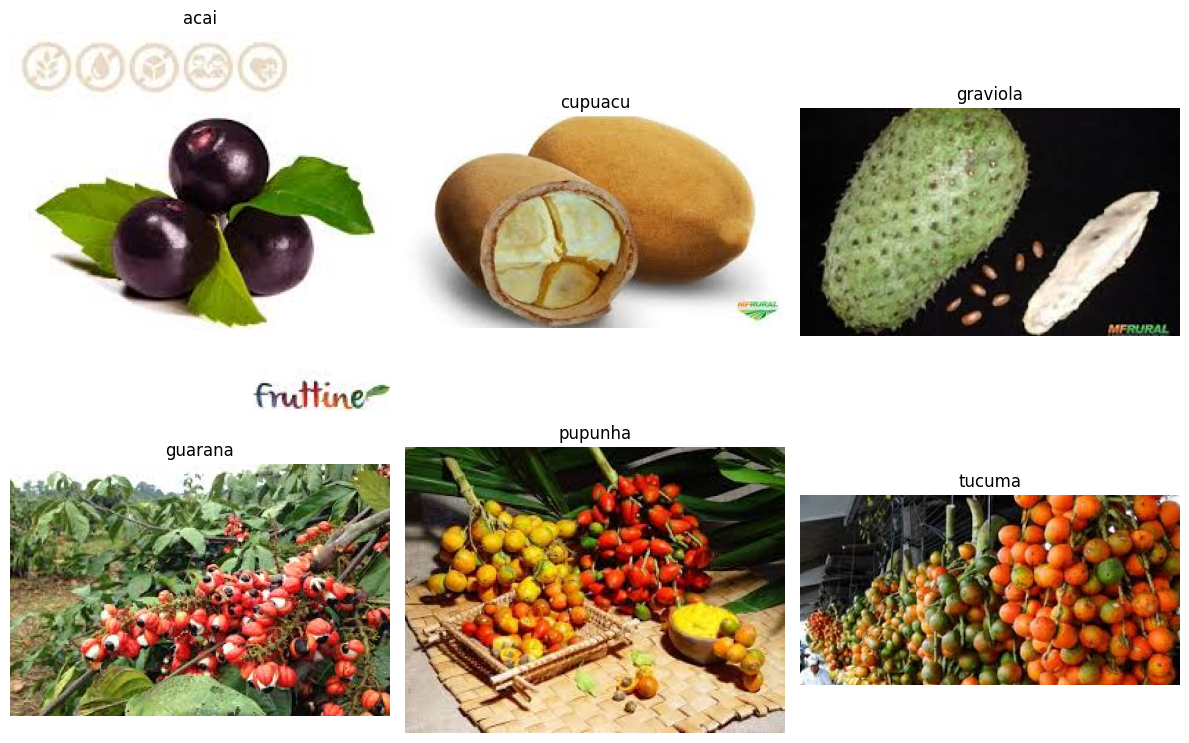

In [4]:
# -----------------------------
# 4. TASK 1 - VISUALIZE ONE RANDOM IMAGE FROM EACH CLASS
# -----------------------------
image_paths = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [
        os.path.join(class_path, img)
        for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    
    if images:
        image_paths.append((class_name, random.choice(images)))

num_images = len(image_paths)
rows = 2
cols = int(np.ceil(num_images / rows))

plt.figure(figsize=(4 * cols, 8))

for i, (class_name, img_path) in enumerate(image_paths, start=1):
    plt.subplot(rows, cols, i)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# =========================
# TASK 1B
# CHECK AND REMOVE CORRUPTED IMAGES
# =========================

def remove_corrupted_images(data_dir):
    corrupted_images = []

    classes = [
        folder for folder in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, folder))
    ]

    for class_name in classes:
        class_path = os.path.join(data_dir, class_name)

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            if not file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                continue

            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, SyntaxError, OSError):
                corrupted_images.append(file_path)
                os.remove(file_path)
                print(f"Removed corrupted image: {file_path}")

    if len(corrupted_images) == 0:
        print(f"No corrupted images found in {data_dir}")
    else:
        print(f"Total corrupted images removed from {data_dir}: {len(corrupted_images)}")


remove_corrupted_images(train_dir)
remove_corrupted_images(test_dir)

No corrupted images found in FruitinAmazon/train
No corrupted images found in FruitinAmazon/test


In [6]:
# -----------------------------
# 6. TASK 2 - LOAD TRAINING DATASET
# -----------------------------
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [5]:
# =========================
# TASK 2
# LOAD AND PREPROCESS IMAGE DATA
# =========================

# Load raw training dataset
raw_train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=seed
)

# Load raw validation dataset
raw_val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=seed
)

# Load raw test dataset
raw_test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False
)

# Save class names before normalization
class_names = raw_train_ds.class_names
num_classes = len(class_names)

print("Class Names:", class_names)
print("Number of Classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of Classes: 6


In [6]:
# =========================
# NORMALIZATION
# =========================

rescale = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = raw_train_ds.map(lambda x, y: (rescale(x), y))
val_ds = raw_val_ds.map(lambda x, y: (rescale(x), y))
test_ds = raw_test_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [7]:
# =========================
# TASK 3
# BUILD CNN MODEL
# =========================

model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    # Convolutional Layer 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), strides=1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# =========================
# TASK 4
# COMPILE THE MODEL
# =========================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [9]:
# =========================
# TASK 4
# TRAIN THE MODEL
# =========================

checkpoint = ModelCheckpoint(
    filepath="best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.2163 - loss: 2.2415
Epoch 1: val_accuracy improved from -inf to 0.11111, saving model to best_fruit_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.2173 - loss: 2.2402 - val_accuracy: 0.1111 - val_loss: 1.7513
Epoch 2/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.3255 - loss: 1.7635
Epoch 2: val_accuracy did not improve from 0.11111
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.2957 - loss: 1.7584 - val_accuracy: 0.0000e+00 - val_loss: 1.8038
Epoch 3/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.3607 - loss: 1.6891
Epoch 3: val_accuracy improved from 0.11111 to 0.66667, saving model to best_fruit_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.3655 - loss: 1.6711 - val_accuracy: 0.6667 - val_loss: 1.5785
Epoch 4/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4779 - loss: 1.5260
Epoch 4: val_accuracy improved from 0.66667 to 0.77778, saving model to best_fruit_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4667 - loss: 1.5026 - val_accuracy: 0.7778 - val_loss: 1.3060
Epoch 5/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6133 - loss: 1.2934
Epoch 5: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6264 - loss: 1.2554 - val_accuracy: 0.5556 - val_loss: 1.1835
Epoch 6/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6966 - loss: 0.9933
Epoch 6: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7098 - loss: 0.9521 - val_accuracy: 0.3333 - val_loss: 1.1328
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8399 - loss: 0.6875
Epoch 7: val_accuracy improved from 0.77778 to 0.83333, saving model to best_fruit_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8365 - loss: 0.6761 - val_accuracy: 0.8333 - val_loss: 0.9556
Epoch 8/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8190 - loss: 0.5052
Epoch 8: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8377 - loss: 0.4802 - val_accuracy: 0.7778 - val_loss: 0.7916
Epoch 9/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9206 - loss: 0.2808
Epoch 9: val_accuracy improved from 0.83333 to 0.88889, saving model to best_fruit_model.h5


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9239 - loss: 0.2684 - val_accuracy: 0.8889 - val_loss: 0.4872
Epoch 10/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9961 - loss: 0.1444
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.9928 - loss: 0.1363 - val_accuracy: 0.8333 - val_loss: 0.7547
Epoch 11/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0987
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.0888 - val_accuracy: 0.8889 - val_loss: 0.4245
Epoch 12/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0570
Epoch 12: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.0526 - val_accuracy: 0.8889 - val_loss: 0.4732
Epoch 13/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.0288
Epoch 13: val_accuracy did not improve from 0.88

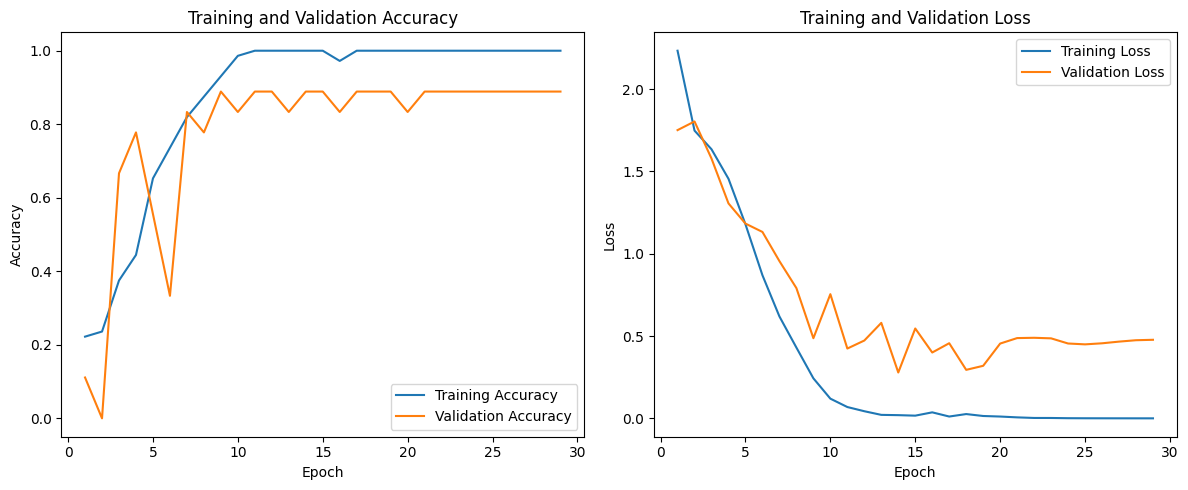

In [10]:
# =========================
# VISUALIZATION
# TRAINING AND VALIDATION GRAPHS
# =========================

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(accuracy) + 1)

plt.figure(figsize=(12, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# =========================
# TASK 5
# EVALUATE THE MODEL ON TEST SET
# =========================

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5639 - loss: 1.0909
Test Loss: 1.0921
Test Accuracy: 0.5333


In [14]:
# =========================
# TASK 6
# SAVE THE MODEL
# =========================

model.save("fruit_classification_model.h5")
print("Model saved successfully as fruit_classification_model.h5")

Model saved successfully as fruit_classification_model.h5


In [15]:
# =========================
# TASK 6
# LOAD THE SAVED MODEL
# =========================

loaded_model = load_model("fruit_classification_model.h5")
print("Saved model loaded successfully.")

Saved model loaded successfully.


In [16]:
# =========================
# RE-EVALUATE LOADED MODEL
# =========================

loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds, verbose=1)

print(f"Loaded Model Test Loss: {loaded_test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5639 - loss: 1.0909 
Loaded Model Test Loss: 1.0921
Loaded Model Test Accuracy: 0.5333


In [17]:
# =========================
# TASK 7
# MAKE PREDICTIONS
# =========================

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Prediction completed.")

Prediction completed.


In [18]:
# =========================
# TASK 7
# CLASSIFICATION REPORT
# =========================

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

        acai       1.00      0.60      0.75         5
     cupuacu       0.50      0.40      0.44         5
    graviola       0.45      1.00      0.62         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.17      0.20      0.18         5

    accuracy                           0.53        30
   macro avg       0.65      0.53      0.54        30
weighted avg       0.65      0.53      0.54        30



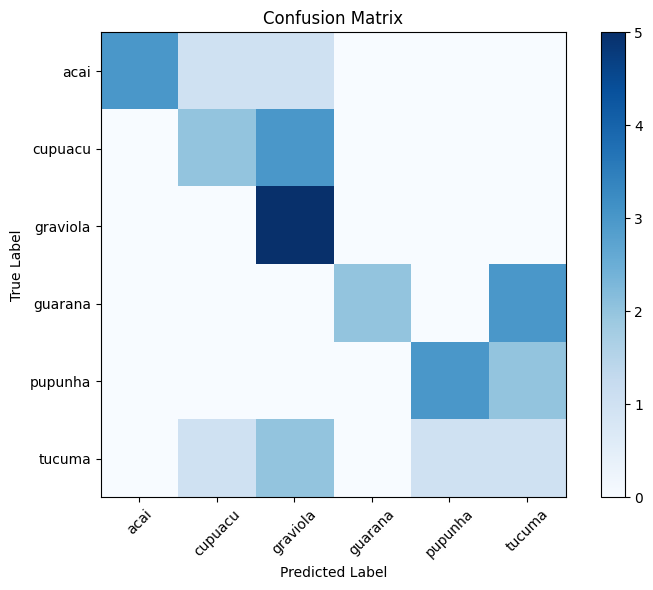

In [19]:
# =========================
# OPTIONAL
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

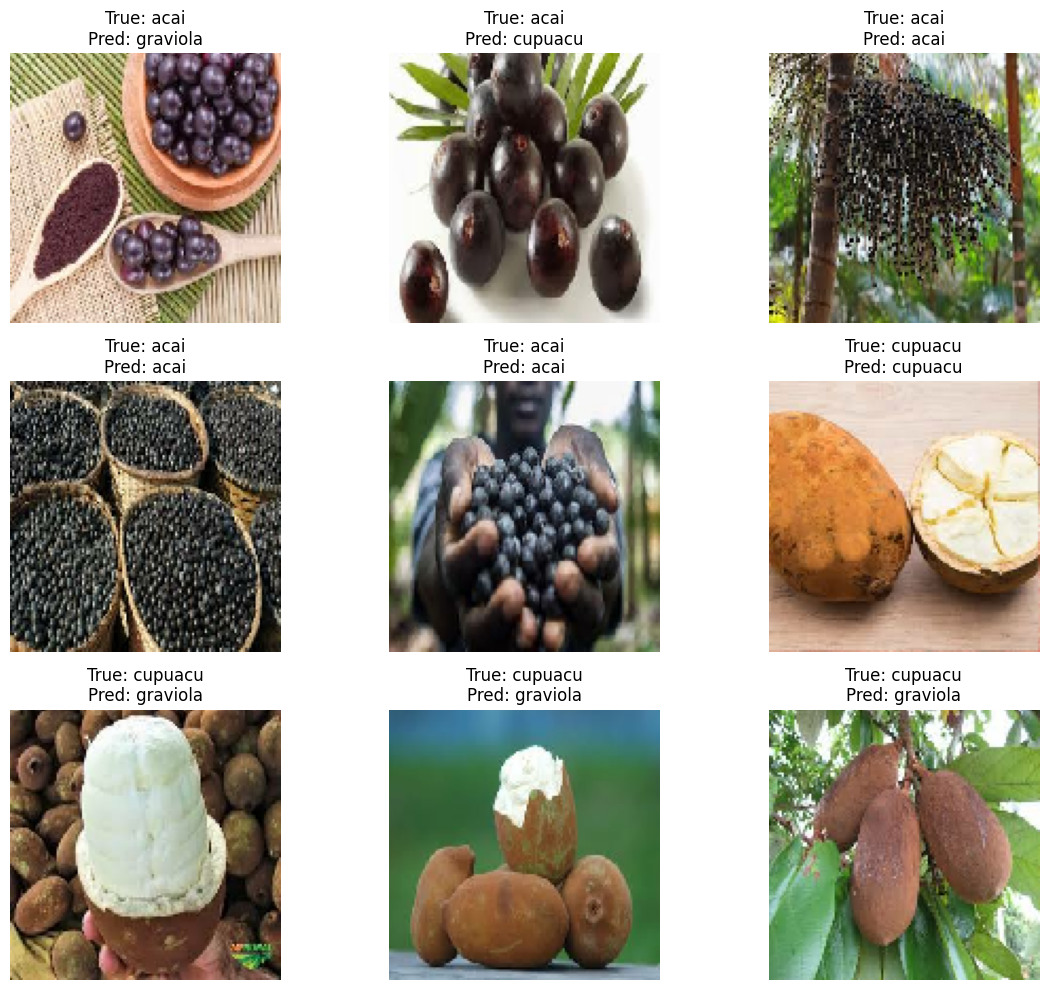

In [20]:
# =========================
# OPTIONAL
# SHOW SOME TEST PREDICTIONS
# =========================

plt.figure(figsize=(12, 10))

for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        true_label = class_names[labels[i].numpy()]
        pred_label = class_names[predicted_labels[i]]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()